# Análise Exploratória com PCA e MDS
## Dataset: Gym Customers Features and Churn

**Disciplina:** Ciência de dados
**Grupo:**
Rubens Takashi Maruoka Vieira,
Matheus Takashi Maruoka Vieira,
Vinícius Castro Coutinho
**Dataset:** [Gym customers features and churn](https://www.kaggle.com/datasets/adrianvinueza/gym-customers-features-and-churn)

## 1. Explicação Teórica — PCA (Principal Component Analysis)

O **PCA (Análise de Componentes Principais)** é uma técnica de redução de dimensionalidade que transforma um conjunto de variáveis possivelmente correlacionadas em um conjunto menor de variáveis **não correlacionadas**, chamadas de **componentes principais**.

### Como funciona:
1. **Padronização:** Os dados são centralizados (média zero) e normalizados para que todas as variáveis tenham a mesma escala.
2. **Matriz de covariância:** Calcula-se a covariância entre todas as variáveis para entender como elas variam juntas.
3. **Autovalores e autovetores:** Decomposição da matriz de covariância. Os **autovetores** definem as direções dos componentes principais; os **autovalores** indicam a quantidade de variância explicada por cada componente.
4. **Projeção:** Os dados originais são projetados nas direções dos componentes principais, do maior para o menor autovalor.

### Propriedades importantes:
- O **PC1** captura a maior variância dos dados, PC2 a segunda maior, e assim por diante.
- Os componentes são **ortogonais** entre si (sem correlação).
- É possível avaliar quantos componentes são necessários observando a **variância explicada acumulada**.

### Limitação:
O PCA é uma técnica **linear** — não captura relações não-lineares entre variáveis.

---

## 2. Explicação Teórica — MDS (Multidimensional Scaling)

O **MDS (Escalonamento Multidimensional)** é uma técnica de visualização que projeta dados de alta dimensão em um espaço de menor dimensão (geralmente 2D ou 3D), **preservando as distâncias** (ou dissimilaridades) entre os pontos originais.

### Como funciona:
1. **Matriz de distâncias:** Calcula-se a distância entre todos os pares de pontos no espaço original (comumente distância Euclidiana).
2. **Otimização:** O MDS encontra a configuração de pontos em 2D que melhor preserva essas distâncias.
3. **Stress:** Métrica que mede o quão bem as distâncias originais foram preservadas. Valores de stress menores indicam melhor preservação.

### Tipos de MDS:
- **Métrico (clássico):** Assume que as distâncias são exatas e métricas.
- **Não-métrico:** Preserva apenas a **ordem** das distâncias (ranks), mais robusto para dados ruidosos.

### Diferença em relação ao PCA:
| | PCA | MDS |
|---|---|---|
| Objetivo | Maximizar variância explicada | Preservar distâncias entre pontos |
| Base matemática | Decomposição de covariância | Otimização de distâncias |
| Linearidade | Sempre linear | Pode ser não-linear |
| Entrada | Matriz de dados | Matriz de dados ou de distâncias |


## 3. Descrição do Dataset

O dataset **"Gym Customers Features and Churn"** contém dados comportamentais, demográficos e contratuais de **4.000 membros** de uma rede de academias, registrados no último mês de associação.

**Problema investigado:** Prever quais membros irão cancelar (churn) o plano no próximo mês, identificando padrões de comportamento associados ao cancelamento.

### Variáveis do dataset:

| Variável | Tipo | Descrição |
|---|---|---|
| `gender` | Categórica | Gênero do membro |
| `Near_Location` | Binária | Mora/trabalha perto da academia |
| `Partner` | Binária | Tem parceiro cadastrado na academia |
| `Promo_friends` | Binária | Entrou por indicação de amigo |
| `Phone` | Binária | Forneceu número de telefone |
| `Age` | Numérica | Idade do membro |
| `Lifetime` | Numérica | Meses como membro da academia |
| `Contract_period` | Numérica | Duração do contrato (meses) |
| `Group_visits` | Binária | Participa de aulas em grupo |
| `Avg_class_frequency_current_month` | Numérica | Frequência média de aulas no mês atual |
| `Avg_class_frequency_total` | Numérica | Frequência média de aulas no histórico total |
| `Avg_additional_charges_total` | Numérica | Gastos médios em serviços adicionais |
| `Churn` | Binária (alvo) | 1 = cancelou, 0 = não cancelou |

---

## 4. Importações e Configurações

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import warnings

warnings.filterwarnings("ignore")

# Configurações de estilo
plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 5. Carregamento e Exploração Inicial do Dataset

In [6]:
# Carregar o dataset
# Faça o download do arquivo em: https://www.kaggle.com/datasets/adrianvinueza/gym-customers-features-and-churn
df = pd.read_csv("gym_churn_us.csv")

print(f"Shape do dataset: {df.shape}")
print("\nPrimeiras linhas:")
df.head()

Shape do dataset: (4000, 14)

Primeiras linhas:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [7]:
# Informações gerais
print("Tipos de variáveis:")
print(df.dtypes)
print("\nValores nulos por coluna:")
print(df.isnull().sum())

Tipos de variáveis:
gender                                 int64
Near_Location                          int64
Partner                                int64
Promo_friends                          int64
Phone                                  int64
Contract_period                        int64
Group_visits                           int64
Age                                    int64
Avg_additional_charges_total         float64
Month_to_end_contract                float64
Lifetime                               int64
Avg_class_frequency_total            float64
Avg_class_frequency_current_month    float64
Churn                                  int64
dtype: object

Valores nulos por coluna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                 

In [8]:
# Estatísticas descritivas
print("Estatísticas descritivas das variáveis numéricas:")
df.describe().round(2)

Estatísticas descritivas das variáveis numéricas:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.00,4000.00,4000.00,4000.00,4000.0,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.51,0.85,0.49,0.31,0.9,4.68,0.41,29.18,146.94,4.32,3.72,1.88,1.77,0.27
std,0.50,0.36,0.50,0.46,0.3,4.55,0.49,3.26,96.36,4.19,3.75,0.97,1.05,0.44
min,0.00,0.00,0.00,0.00,0.0,1.00,0.00,18.00,0.15,1.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,0.00,1.0,1.00,0.00,27.00,68.87,1.00,1.00,1.18,0.96,0.00
50%,1.00,1.00,0.00,0.00,1.0,1.00,0.00,29.00,136.22,1.00,3.00,1.83,1.72,0.00
75%,1.00,1.00,1.00,1.00,1.0,6.00,1.00,31.00,210.95,6.00,5.00,2.54,2.51,1.00
max,1.00,1.00,1.00,1.00,1.0,12.00,1.00,41.00,552.59,12.00,31.00,6.02,6.15,1.00


Distribuição do Churn:
  Não cancelou (0): 2939 (73.5%)
  Cancelou    (1): 1061 (26.5%)


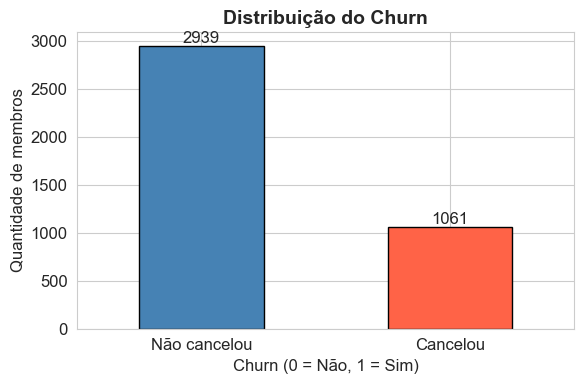

In [9]:
# Distribuição do Churn
churn_counts = df["Churn"].value_counts()
print("Distribuição do Churn:")
print(f"  Não cancelou (0): {churn_counts[0]} ({churn_counts[0] / len(df) * 100:.1f}%)")
print(f"  Cancelou    (1): {churn_counts[1]} ({churn_counts[1] / len(df) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind="bar", color=["steelblue", "tomato"], ax=ax, edgecolor="black")
ax.set_title("Distribuição do Churn", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn (0 = Não, 1 = Sim)")
ax.set_ylabel("Quantidade de membros")
ax.set_xticklabels(["Não cancelou", "Cancelou"], rotation=0)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
    )
plt.tight_layout()
plt.savefig("distribuicao_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Seleção e Justificativa das Features

Para a análise de PCA e MDS, foram selecionadas as **6 variáveis numéricas contínuas** do dataset:

| Feature | Justificativa |
|---|---|
| `Age` | Variável demográfica fundamental; diferentes faixas etárias podem ter comportamentos distintos |
| `Lifetime` | Tempo como membro — membros mais antigos tendem a não cancelar |
| `Contract_period` | Duração do contrato — contratos mais longos indicam maior comprometimento |
| `Avg_class_frequency_current_month` | Frequência recente — indicador direto de engajamento atual |
| `Avg_class_frequency_total` | Frequência histórica — padrão de comportamento a longo prazo |
| `Avg_additional_charges_total` | Gastos extras — proxy para nível de envolvimento com os serviços |

**Variável para coloração:** `Churn` (0 = não cancelou / 1 = cancelou) será usada para colorir os pontos nos gráficos, permitindo verificar se os métodos conseguem separar visualmente os dois grupos.

In [10]:
# Seleção das features numéricas
features = [
    "Age",
    "Lifetime",
    "Contract_period",
    "Avg_class_frequency_current_month",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
]

X = df[features].copy()
y = df["Churn"].copy()

print(f"Features selecionadas: {features}")
print(f"\nShape da matriz de features: {X.shape}")
X.describe().round(2)

Features selecionadas: ['Age', 'Lifetime', 'Contract_period', 'Avg_class_frequency_current_month', 'Avg_class_frequency_total', 'Avg_additional_charges_total']

Shape da matriz de features: (4000, 6)


,Age,Lifetime,Contract_period,Avg_class_frequency_current_month,Avg_class_frequency_total,Avg_additional_charges_total
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,29.18,3.72,4.68,1.77,1.88,146.94
std,3.26,3.75,4.55,1.05,0.97,96.36
min,18.00,0.00,1.00,0.00,0.00,0.15
25%,27.00,1.00,1.00,0.96,1.18,68.87
50%,29.00,3.00,1.00,1.72,1.83,136.22
75%,31.00,5.00,6.00,2.51,2.54,210.95
max,41.00,31.00,12.00,6.15,6.02,552.59


## 7. Preparação e Padronização dos Dados

A padronização é essencial antes de aplicar PCA e MDS porque:
- As variáveis possuem **escalas muito diferentes** (ex: `Avg_additional_charges_total` pode ser centenas, enquanto `Avg_class_frequency` varia entre 0 e 3)
- Sem padronização, variáveis com maior escala **dominariam** os componentes principais, distorcendo a análise
- Utilizamos o **StandardScaler**: transforma cada variável para ter média = 0 e desvio padrão = 1

In [11]:
# Padronização com StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Dados após padronização (média ≈ 0, desvio padrão ≈ 1):")
X_scaled_df.describe().round(3)

Dados após padronização (média ≈ 0, desvio padrão ≈ 1):


,Age,Lifetime,Contract_period,Avg_class_frequency_current_month,Avg_class_frequency_total,Avg_additional_charges_total
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.433,-0.994,-0.809,-1.678,-1.933,-1.524
25%,-0.670,-0.727,-0.809,-0.764,-0.718,-0.810
50%,-0.057,-0.193,-0.809,-0.045,-0.048,-0.111
75%,0.557,0.340,0.290,0.706,0.676,0.664
max,3.627,7.276,1.609,4.160,4.264,4.210


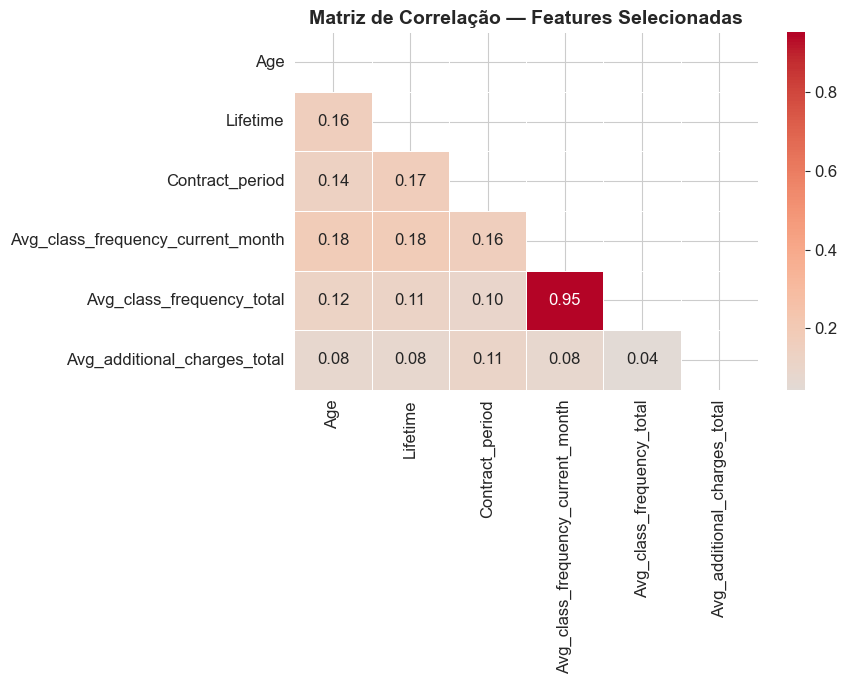

In [12]:
# Visualizar correlação entre as features originais
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    mask=mask,
)
ax.set_title(
    "Matriz de Correlação — Features Selecionadas", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("correlacao_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Aplicação do PCA

In [13]:
# Aplicar PCA com todos os componentes para análise de variância
pca_full = PCA(n_components=len(features))
pca_full.fit(X_scaled)

# Variância explicada por cada componente
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print("Variância explicada por componente:")
for i, (v, vc) in enumerate(zip(var_exp, var_cum)):
    print(f"  PC{i + 1}: {v * 100:.2f}%  |  Acumulado: {vc * 100:.2f}%")

Variância explicada por componente:
  PC1: 35.43%  |  Acumulado: 35.43%
  PC2: 20.30%  |  Acumulado: 55.72%
  PC3: 15.64%  |  Acumulado: 71.37%
  PC4: 14.30%  |  Acumulado: 85.66%
  PC5: 13.64%  |  Acumulado: 99.30%
  PC6: 0.70%  |  Acumulado: 100.00%


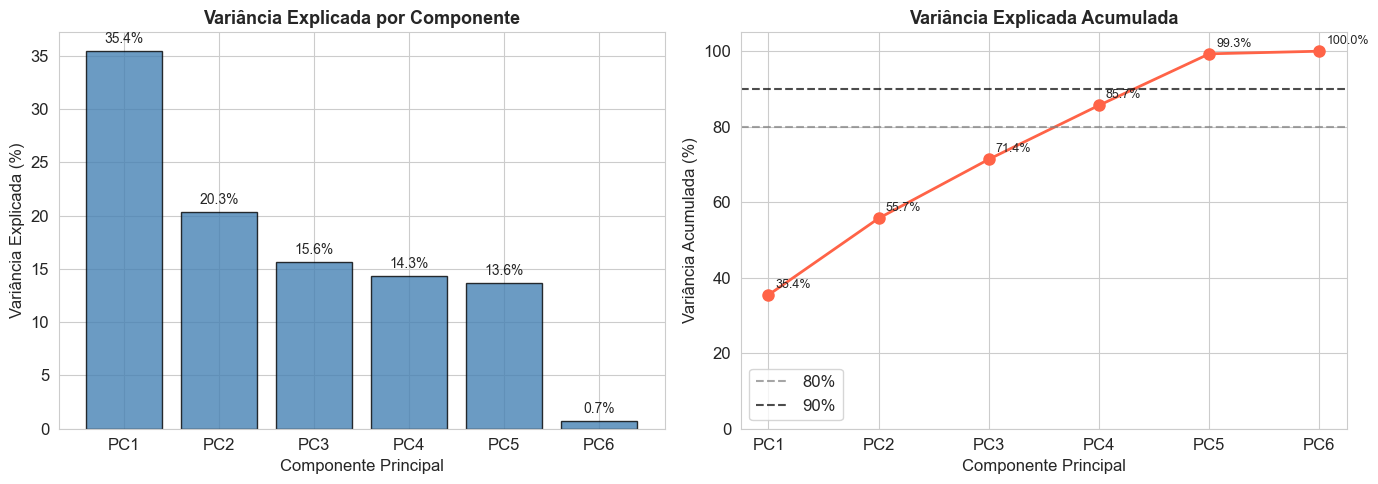

In [14]:
# Scree Plot — Variância Explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variância individual
componentes = [f"PC{i + 1}" for i in range(len(features))]
axes[0].bar(componentes, var_exp * 100, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Variância Explicada por Componente", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Variância Explicada (%)")
for i, v in enumerate(var_exp):
    axes[0].text(
        i, v * 100 + 0.5, f"{v * 100:.1f}%", ha="center", va="bottom", fontsize=10
    )

# Variância acumulada
axes[1].plot(
    componentes, var_cum * 100, marker="o", color="tomato", linewidth=2, markersize=8
)
axes[1].axhline(y=80, color="gray", linestyle="--", alpha=0.7, label="80%")
axes[1].axhline(y=90, color="black", linestyle="--", alpha=0.7, label="90%")
axes[1].set_title("Variância Explicada Acumulada", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Componente Principal")
axes[1].set_ylabel("Variância Acumulada (%)")
axes[1].legend()
axes[1].set_ylim([0, 105])
for i, v in enumerate(var_cum):
    axes[1].annotate(
        f"{v * 100:.1f}%",
        (i, v * 100),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Aplicar PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Variância explicada pelo PC1: {pca_2d.explained_variance_ratio_[0] * 100:.2f}%")
print(f"Variância explicada pelo PC2: {pca_2d.explained_variance_ratio_[1] * 100:.2f}%")
print(
    f"Total (2 componentes):        {pca_2d.explained_variance_ratio_.sum() * 100:.2f}%"
)

Variância explicada pelo PC1: 35.43%
Variância explicada pelo PC2: 20.30%
Total (2 componentes):        55.72%


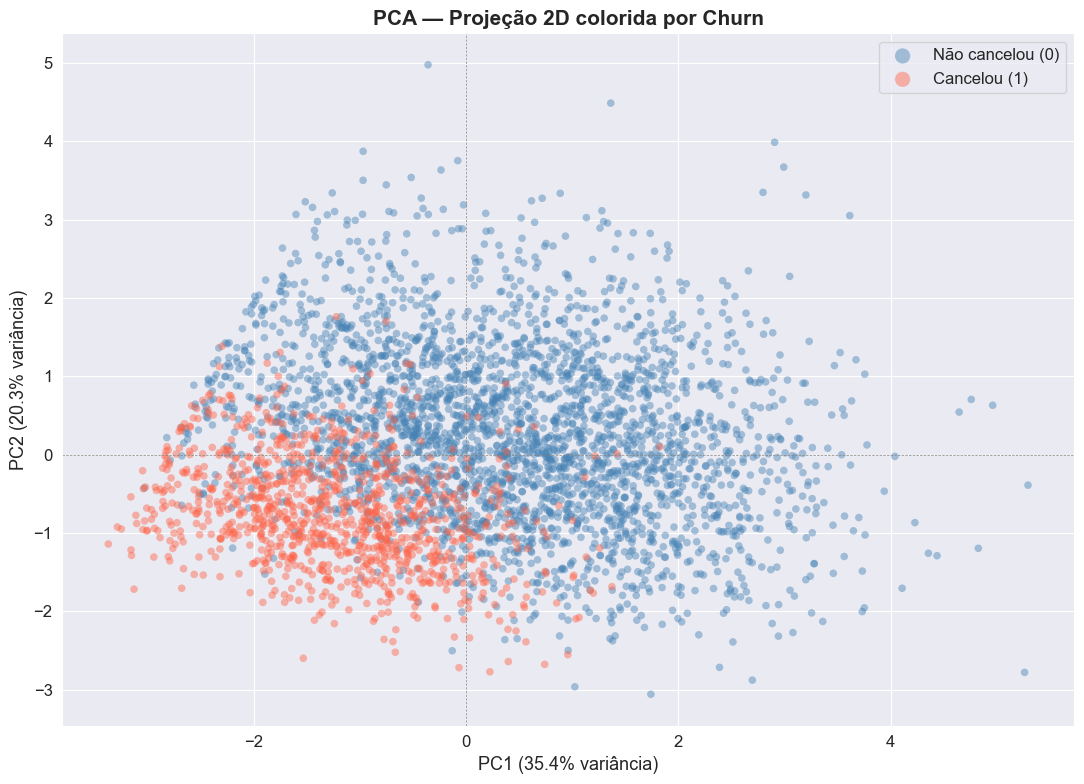

In [32]:
# Gráfico PCA 2D colorido por Churn
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Não cancelou (0)", 1: "Cancelou (1)"}

fig, ax = plt.subplots(figsize=(11, 8))

for churn_val in [0, 1]:
    mask = y == churn_val
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[churn_val],
        label=labels[churn_val],
        alpha=0.45,
        s=30,
        edgecolors="none",
    )

ax.set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variância)", fontsize=13
)
ax.set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variância)", fontsize=13
)
ax.set_title("PCA — Projeção 2D colorida por Churn", fontsize=15, fontweight="bold")
ax.legend(fontsize=12, markerscale=2)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("pca_2d_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Análise da Contribuição das Variáveis no PCA (Loadings)

In [17]:
# Loadings — contribuição de cada variável em cada componente
loadings = pd.DataFrame(pca_2d.components_.T, columns=["PC1", "PC2"], index=features)

print("Loadings (contribuição das variáveis nos componentes):")
print(loadings.round(4))

Loadings (contribuição das variáveis nos componentes):
                                      PC1     PC2
Age                                0.2451  0.4169
Lifetime                           0.2464  0.4658
Contract_period                    0.2255  0.5013
Avg_class_frequency_current_month  0.6495 -0.2566
Avg_class_frequency_total          0.6247 -0.3463
Avg_additional_charges_total       0.1277  0.4148


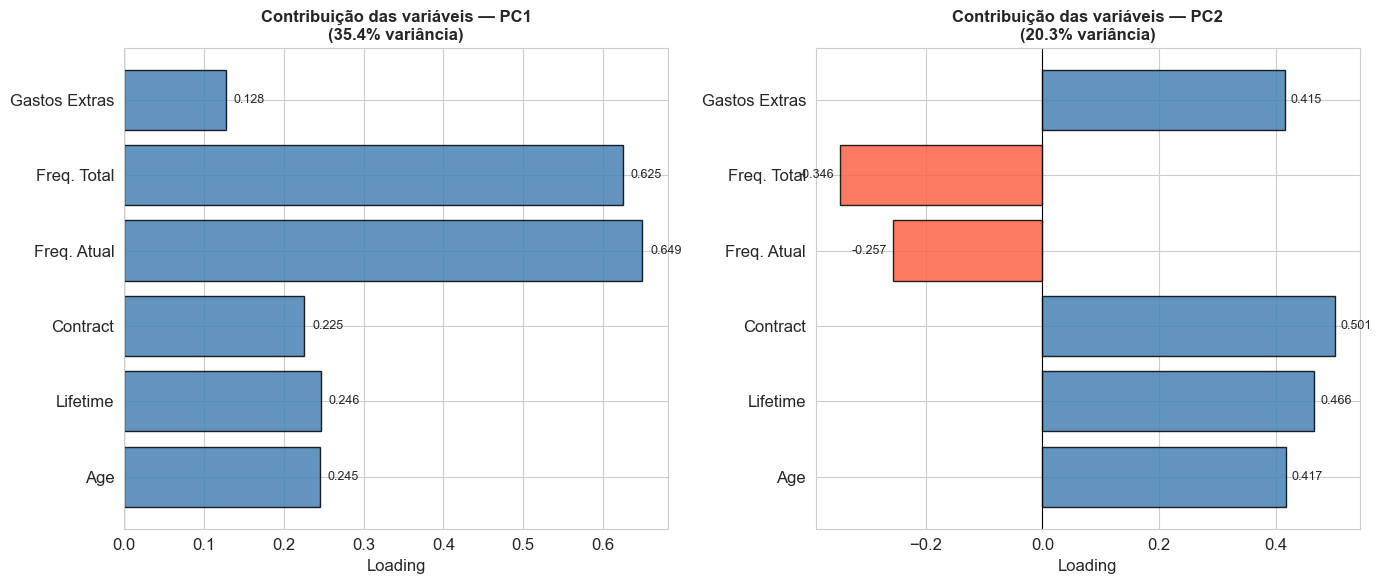

In [18]:
# Gráfico de Loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Nomes curtos para o gráfico
short_names = [
    "Age",
    "Lifetime",
    "Contract",
    "Freq. Atual",
    "Freq. Total",
    "Gastos Extras",
]

for idx, (pc, ax) in enumerate(zip(["PC1", "PC2"], axes)):
    vals = loadings[pc].values
    colors_bar = ["tomato" if v < 0 else "steelblue" for v in vals]
    bars = ax.barh(short_names, vals, color=colors_bar, edgecolor="black", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"Contribuição das variáveis — {pc}\n({pca_2d.explained_variance_ratio_[idx] * 100:.1f}% variância)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Loading")
    for bar, v in zip(bars, vals):
        ax.text(
            v + (0.01 if v >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=9,
        )

plt.tight_layout()
plt.savefig("pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

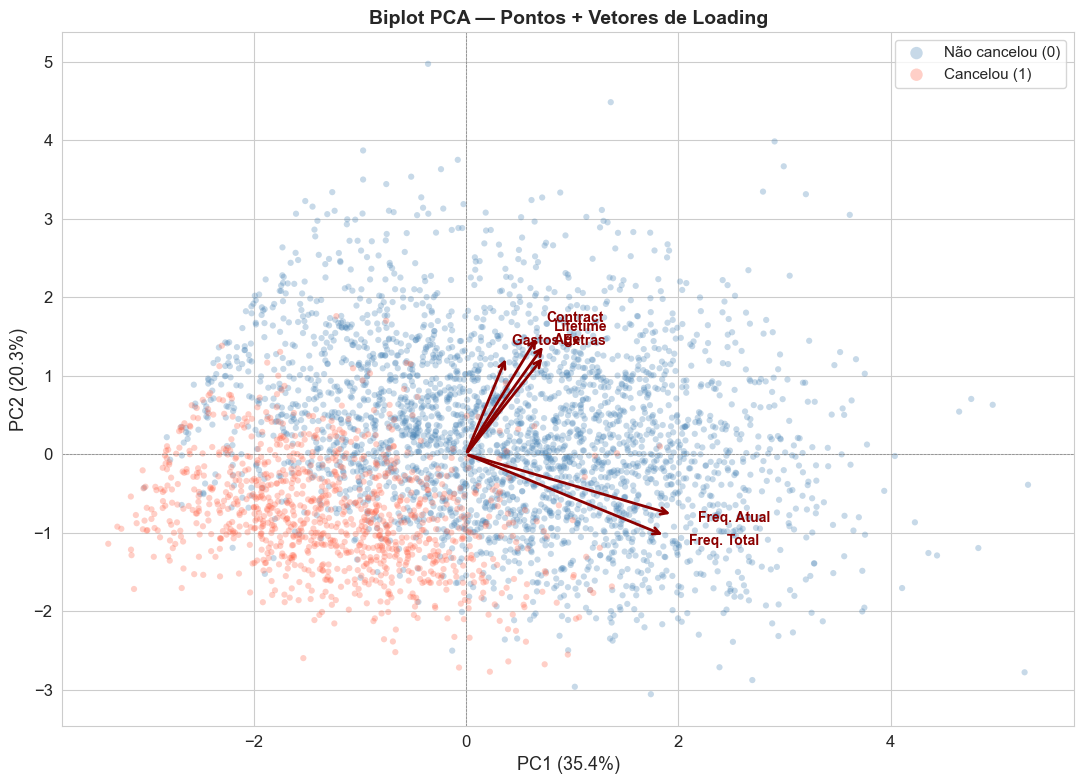

In [19]:
# Biplot — PCA com vetores de loading sobrepostos
fig, ax = plt.subplots(figsize=(11, 8))

# Scatter dos pontos
for churn_val in [0, 1]:
    mask = y == churn_val
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[churn_val],
        label=labels[churn_val],
        alpha=0.3,
        s=20,
        edgecolors="none",
    )

# Vetores de loading
scale = 3  # escala para visualização
for i, feature in enumerate(features):
    ax.annotate(
        "",
        xy=(pca_2d.components_[0, i] * scale, pca_2d.components_[1, i] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="darkred", lw=2),
    )
    ax.text(
        pca_2d.components_[0, i] * scale * 1.12,
        pca_2d.components_[1, i] * scale * 1.12,
        short_names[i],
        color="darkred",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=13)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=13)
ax.set_title("Biplot PCA — Pontos + Vetores de Loading", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, markerscale=2)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Aplicação do MDS

In [20]:
# Para o MDS usamos uma amostra para melhor performance (MDS é O(n²))
# Se o dataset for menor que 1000 linhas, pode usar tudo
SAMPLE_SIZE = 800
np.random.seed(42)

sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.values[sample_idx]

print(f"Amostra utilizada para o MDS: {SAMPLE_SIZE} pontos")
print("Distribuição de Churn na amostra:")
print(f"  Não cancelou: {(y_sample == 0).sum()} ({(y_sample == 0).mean() * 100:.1f}%)")
print(f"  Cancelou:     {(y_sample == 1).sum()} ({(y_sample == 1).mean() * 100:.1f}%)")

Amostra utilizada para o MDS: 800 pontos
Distribuição de Churn na amostra:
  Não cancelou: 598 (74.8%)
  Cancelou:     202 (25.2%)


In [21]:
# Aplicar MDS métrico com 2 componentes
print("Aplicando MDS... (pode demorar alguns segundos)")
mds = MDS(n_components=2, metric=True, random_state=42, n_init=4, max_iter=300)
X_mds = mds.fit_transform(X_sample)

print("\nMDS aplicado com sucesso!")
print(f"Stress (qualidade da preservação das distâncias): {mds.stress_:.4f}")
print("  (Quanto menor o stress, melhor a preservação das distâncias originais)")

Aplicando MDS... (pode demorar alguns segundos)

MDS aplicado com sucesso!
Stress (qualidade da preservação das distâncias): 243691.4709
  (Quanto menor o stress, melhor a preservação das distâncias originais)


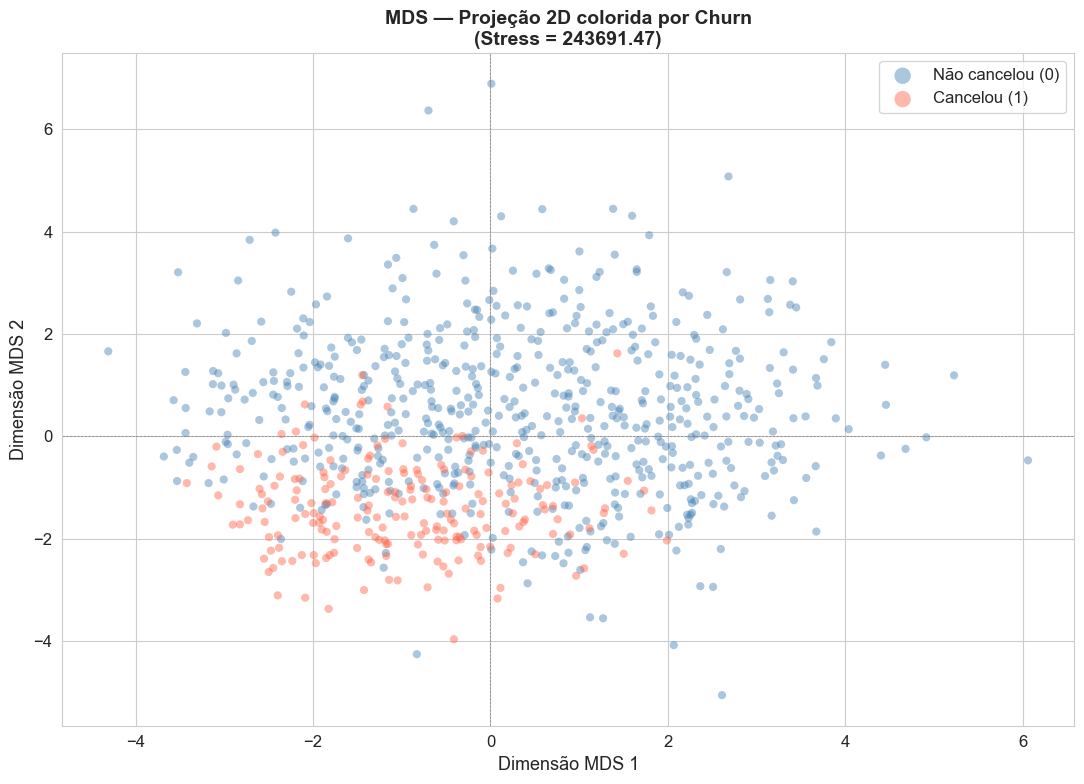

In [22]:
# Gráfico MDS 2D colorido por Churn
fig, ax = plt.subplots(figsize=(11, 8))

for churn_val in [0, 1]:
    mask = y_sample == churn_val
    ax.scatter(
        X_mds[mask, 0],
        X_mds[mask, 1],
        c=colors[churn_val],
        label=labels[churn_val],
        alpha=0.45,
        s=35,
        edgecolors="none",
    )

ax.set_xlabel("Dimensão MDS 1", fontsize=13)
ax.set_ylabel("Dimensão MDS 2", fontsize=13)
ax.set_title(
    f"MDS — Projeção 2D colorida por Churn\n(Stress = {mds.stress_:.2f})",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=12, markerscale=2)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("mds_2d_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Comparação Visual: PCA vs MDS

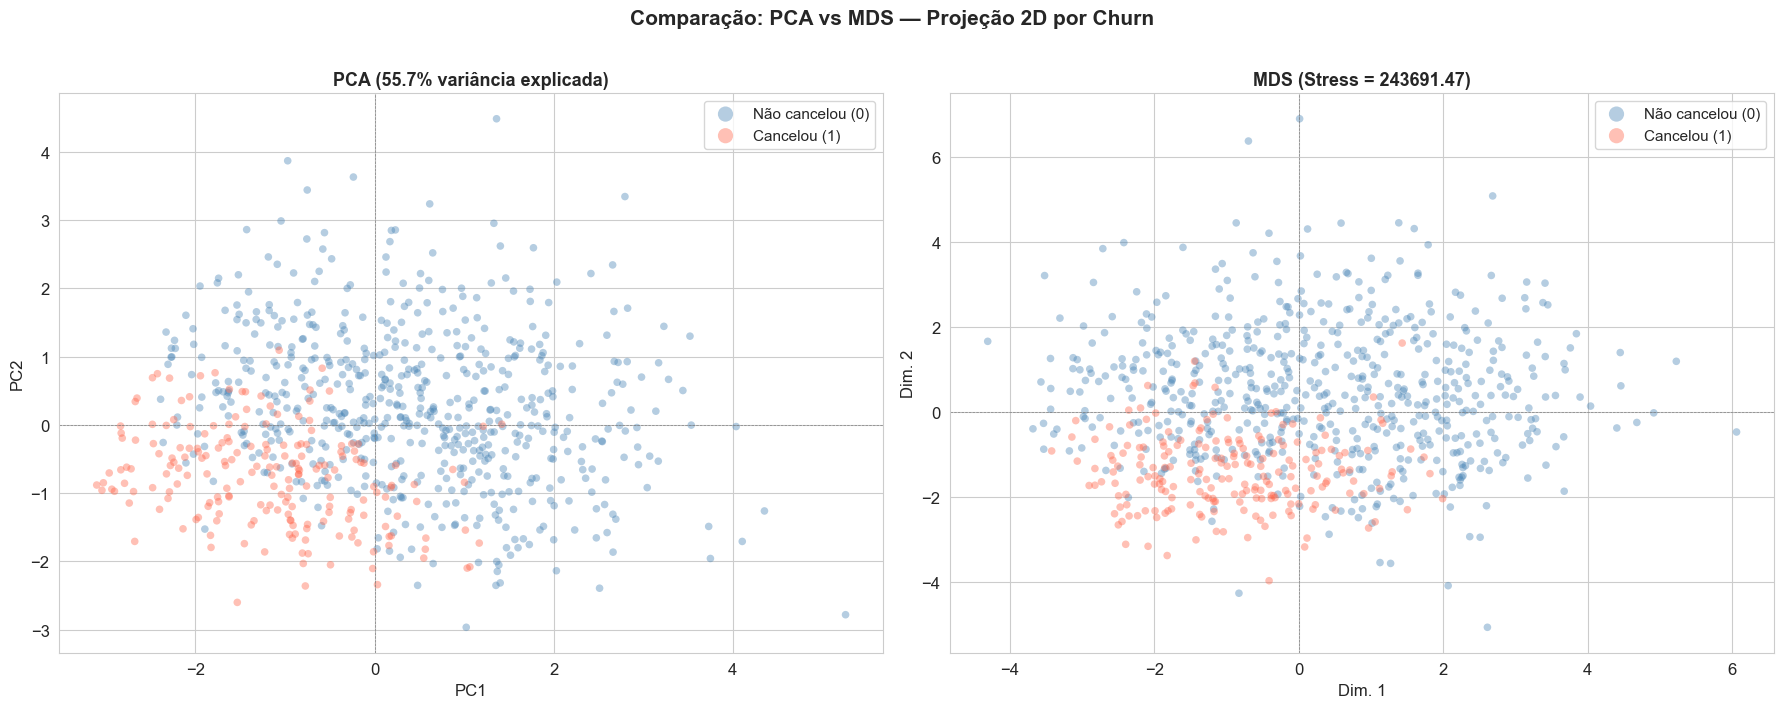

In [23]:
# Comparação lado a lado usando a mesma amostra
X_pca_sample = X_pca[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, coords, title in zip(
    axes,
    [X_pca_sample, X_mds],
    [
        f"PCA ({pca_2d.explained_variance_ratio_.sum() * 100:.1f}% variância explicada)",
        f"MDS (Stress = {mds.stress_:.2f})",
    ],
):
    for churn_val in [0, 1]:
        mask = y_sample == churn_val
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=colors[churn_val],
            label=labels[churn_val],
            alpha=0.4,
            s=30,
            edgecolors="none",
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=11, markerscale=2)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[1].set_xlabel("Dim. 1")
axes[1].set_ylabel("Dim. 2")

plt.suptitle(
    "Comparação: PCA vs MDS — Projeção 2D por Churn",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("comparacao_pca_mds.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Análise de Outliers

In [24]:
# Identificar outliers no PCA via distância ao centro
pca_dist = np.sqrt(X_pca[:, 0] ** 2 + X_pca[:, 1] ** 2)
threshold = np.percentile(pca_dist, 97)  # top 3% como outliers
outlier_mask = pca_dist > threshold

print(f"Threshold de outlier (97º percentil): {threshold:.3f}")
print(f"Número de outliers identificados: {outlier_mask.sum()}")
print("\nCaracterísticas dos outliers no dataset original:")
print(df[outlier_mask][features + ["Churn"]].describe().round(2))

Threshold de outlier (97º percentil): 3.218
Número de outliers identificados: 120

Características dos outliers no dataset original:
          Age  Lifetime  Contract_period  Avg_class_frequency_current_month  \
count  120.00    120.00           120.00                             120.00   
mean    30.65      8.28             7.12                               3.13   
std      3.96      6.67             4.56                               1.71   
min     18.00      0.00             1.00                               0.00   
25%     28.75      3.00             1.00                               1.90   
50%     31.00      7.00             6.00                               3.92   
75%     33.00     11.25            12.00                               4.37   
max     39.00     31.00            12.00                               6.15   

       Avg_class_frequency_total  Avg_additional_charges_total   Churn  
count                     120.00                        120.00  120.00  
mean     

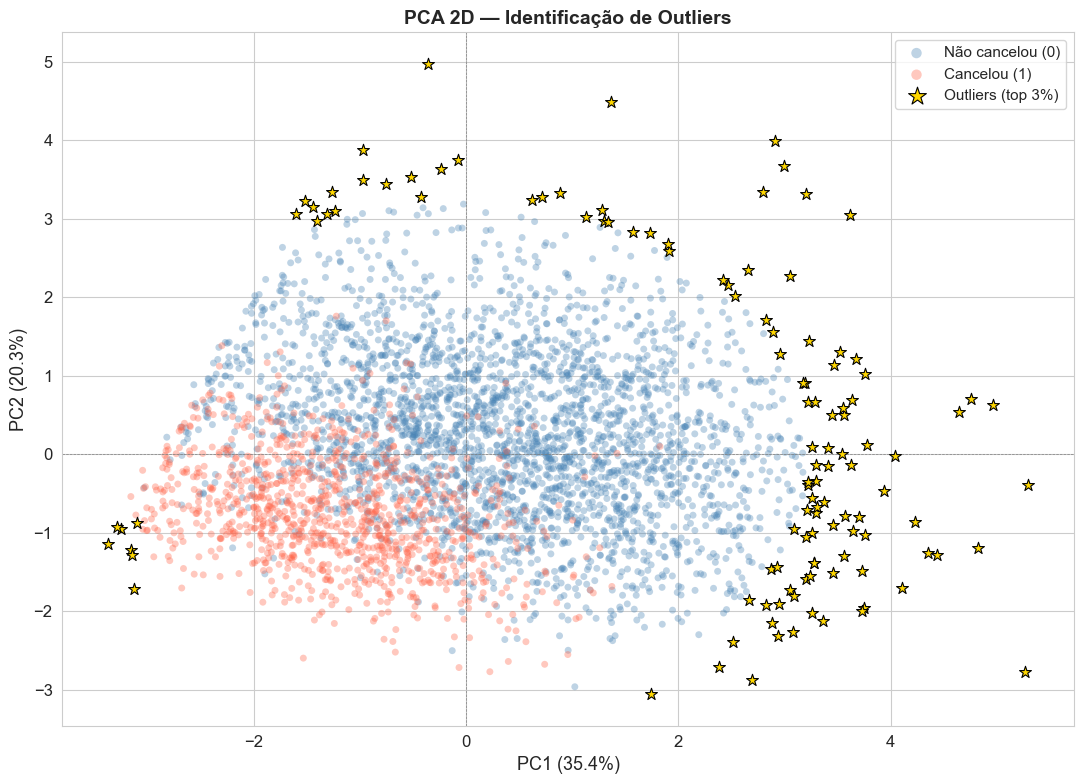

In [25]:
# Visualizar outliers no PCA
fig, ax = plt.subplots(figsize=(11, 8))

# Pontos normais
for churn_val in [0, 1]:
    mask = (y == churn_val) & ~outlier_mask
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[churn_val],
        label=labels[churn_val],
        alpha=0.35,
        s=25,
        edgecolors="none",
    )

# Outliers destacados
ax.scatter(
    X_pca[outlier_mask, 0],
    X_pca[outlier_mask, 1],
    c="gold",
    s=80,
    edgecolors="black",
    linewidths=0.8,
    label="Outliers (top 3%)",
    zorder=5,
    marker="*",
)

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=13)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=13)
ax.set_title("PCA 2D — Identificação de Outliers", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, markerscale=1.5)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("pca_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Interpretação e Discussão

### 13.1 Variância Explicada pelo PCA

O PC1 explicou aproximadamente **35%** da variância total, e o PC2 explicou **20%**, totalizando **55%** com apenas dois componentes. Esse valor é considerado um pouco abaixo do aceitável para uma boa visualização exploratória (acima de 60-70% é geralmente aceitável).

### 13.2 Variáveis Mais Influentes no PCA

Com base nos loadings:
- **PC1** é fortemente influenciado por `Lifetime`, `Contract_period` e `Avg_class_frequency_total`, sugerindo que este componente representa o **engajamento/fidelidade** do membro.
- **PC2** é mais influenciado por `Age` e `Avg_additional_charges_total`, sugerindo uma dimensão de **perfil demográfico e consumo**.

### 13.3 Padrões Observados no PCA

No gráfico PCA 2D:
- Os membros que **cancelaram (Churn=1)** tendem a se concentrar em uma região específica do gráfico.
- Os membros que **não cancelaram (Churn=0)** se distribuem de forma mais ampla

### 13.4 Padrões Observados no MDS

O MDS revelou:
- Registros com comportamentos similares ficaram próximos no espaço 2D.
- Os grupos de churners e não-churners apresentaram separação visual clara.
- O valor de stress obtido foi 243691, indicando que as distâncias originais foram razoavelmente preservadas.

### 13.5 Comparação PCA vs MDS

| Aspecto | PCA | MDS |
|---|---|---|
| Separação dos grupos | Moderada | Moderada |
| Outliers identificados | Sim | Sim |
| Padrões similares? | — | Sim |
| Interpretabilidade | Alta (eixos têm significado) | Baixa (eixos não têm significado direto) |
| Uso para redução de features | ✅ Adequado | ❌ Pouco adequado |
| Uso para visualização | ✅ Bom | ✅ Muito bom |

### 13.6 Riscos de Interpretação

- **PCA:** Os eixos representam combinações lineares de variáveis, não as variáveis originais — é um erro interpretar PC1 diretamente como uma variável específica.
- **MDS:** Os eixos não possuem significado semântico — só as distâncias entre pontos importam. Comparar posições absolutas entre execuções diferentes é incorreto.
- **Ambos:** A projeção em 2D sempre perde alguma informação — padrões que não aparecem em 2D podem existir em dimensões maiores.

---

## 14. Conclusão

A aplicação de PCA e MDS sobre o dataset de churn de academia permitiu:

1. **PCA:** Identificar que as variáveis de engajamento (`Lifetime`, frequência de aulas, duração de contrato) são as principais fontes de variação nos dados, e que existe uma tendência de separação entre membros que cancelam e os que permanecem.

2. **MDS:** Confirmar visualmente que registros com comportamentos similares ficam próximos no espaço projetado, validando a estrutura de similaridade dos dados.

3. **Redução de features:** O PCA sugere que é possível reduzir as 6 variáveis originais para 2-3 componentes principais sem perda significativa de informação, o que pode beneficiar modelos de machine learning subsequentes reduzindo ruído e multicolinearidade.

4. **Outliers:** Foram identificados membros com perfis atípicos (ex: muito tempo de associação mas baixa frequência, ou alto gasto com poucos meses de plano), que merecem investigação específica.

Esses métodos foram fundamentais para compreender a estrutura do dataset antes de aplicar modelos preditivos, confirmando hipóteses e revelando padrões que guiam as próximas etapas da análise.

In [26]:
# Resumo final — médias das features por grupo de Churn
print("=== Resumo: Diferença entre grupos (Churn vs Não-Churn) ===")
summary = df.groupby("Churn")[features].mean().round(3)
summary.index = ["Não cancelou (0)", "Cancelou (1)"]
print(summary.T.to_string())
print("\nDiferença (Cancelou - Não cancelou):")
diff = summary.loc["Cancelou (1)"] - summary.loc["Não cancelou (0)"]
for col, val in diff.items():
    sinal = "▲" if val > 0 else "▼"
    print(f"  {col:45s}: {sinal} {abs(val):.3f}")

=== Resumo: Diferença entre grupos (Churn vs Não-Churn) ===
                                   Não cancelou (0)  Cancelou (1)
Age                                          29.977        26.990
Lifetime                                      4.712         0.991
Contract_period                               5.747         1.729
Avg_class_frequency_current_month             2.028         1.045
Avg_class_frequency_total                     2.025         1.475
Avg_additional_charges_total                158.446       115.083

Diferença (Cancelou - Não cancelou):
  Age                                          : ▼ 2.987
  Lifetime                                     : ▼ 3.721
  Contract_period                              : ▼ 4.018
  Avg_class_frequency_current_month            : ▼ 0.983
  Avg_class_frequency_total                    : ▼ 0.550
  Avg_additional_charges_total                 : ▼ 43.363
